<p> <center><img src="https://datascientest.fr/train/assets/logo_datascientest.png" style="height:200px"> </p>

<hr style="border-width:2px;border-color:#75DFC1">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Features Engineering </h2></center>
<hr style="border-width:2px;border-color:#75DFC1">

# I - Chargement des données PACA

Cette étape consiste à charger le fichier **"paca_meteo_energie.csv"** contenant les données météorologiques et radiatives régionales pour la région PACA avec une résolution temporelle de **30 minutes**.

Les variables disponibles dans ce jeu de données comprennent notamment:

- **`azimuth`** : azimut solaire (en degrés), indiquant la direction du soleil par rapport au nord (0–360° selon la convention).  
- **`altitude`** : altitude solaire (en degrés), représentant l'élévation du soleil au-dessus de l'horizon (valeurs négatives durant la nuit).  
- **`Temperature`** *(souvent `T2M`)* : température de l'air à 2 mètres du sol (en °C ou en K selon la source ; une vérification des unités est nécessaire).  
- **`GHI`** (*Global Horizontal Irradiance*) : irradiance globale reçue sur un plan horizontal (composantes directe et diffuse) exprimée en Wh/m².  
- **`BHI`** (*Beam Horizontal Irradiance*) : composante directe du rayonnement solaire projetée sur le plan horizontal (Wh/m²).  
- **`DHI`** (*Diffuse Horizontal Irradiance*) : composante diffuse du rayonnement solaire reçue sur un plan horizontal (Wh/m²).  
- **`BNI`** (*Beam Normal Irradiance*) : irradiance directe normale, reçue sur un plan perpendiculaire aux rayons solaires (Wh/m²).  
- **`Vitesse_Vent`** *(souvent `V2M`)* : vitesse du vent mesurée à 2 mètres du sol (m/s).  
- **`Nebulosite`** *(souvent `cloud_AMT`)* : nébulosité ou fraction de couverture nuageuse (exprimée selon les produits en fraction, pourcentage ou indice adimensionnel).  
- **`Humidite`** : humidité de l'air (généralement humidité relative en %, ou humidité spécifique selon la source).  
- **`Clear_sky_GHI`** : irradiance globale horizontale en conditions de ciel clair, utilisée comme référence théorique sans nuages (Wh/m²).  
- **`Clear_sky_BHI`** : composante directe horizontale en conditions de ciel clair (Wh/m²).  
- **`Clear_sky_DHI`** : composante diffuse horizontale en conditions de ciel clair (Wh/m²).  
- **`Clear_sky_BNI`** : irradiance directe normale en conditions de ciel clair (Wh/m²).  
- **`TOA`** (*Top Of Atmosphere*) : rayonnement solaire incident au sommet de l'atmosphère (Wh/m²), utilisé pour le contrôle de cohérence et la normalisation des séries.



Nous commencons par importer les librairies nécessaires pour manipuler nos données :

In [1]:
# Gestion des chemins
from pathlib import Path

# Données et calculs
import pandas as pd
import numpy as np

# Dataviz
import matplotlib.pyplot as plt
%matplotlib inline

# Analyse des variables
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_selection import VarianceThreshold


On récupère les données collectées aux étapes précédentes :

In [2]:
# Chemin vers le répertoire de données d'entrée
input_path = Path('../../data/local_data/input/')

# Chemin vers le répertoire de résultats temporaires
temp_path = Path('../../data/local_data/temp/')

# Chemin vers le répertoire de résultats finaux
output_path = Path('../../data/local_data/output/')

# Chemin du dataset de production
input_datasets = output_path / 'raw_2020_2025.csv'


In [3]:
# Lecture du fichier de données brutes 2020-2025 et affichage d'informations générales

# Charger le dataset
df_2020_2025 = pd.read_csv(input_datasets, 
                           index_col='datetime_utc', 
                           parse_dates=True)

# Afficher les premières lignes
display(df_2020_2025)

# Afficher les dimensions du dataset
print('Dimensions df_2020_2025 :', df_2020_2025.shape)

# Afficher les statistiques des variables numériques
display(df_2020_2025.describe())

# Afficher le type des colonnes, les valeurs manquantes
df_2020_2025.info()


,consommation,solaire,tco_solaire,tch_solaire,cru_azimuth,cru_altitude,sel_azimuth,sel_altitude,svt_azimuth,svt_altitude,...,svt_nebulosite,svt_humidite,bra_temperature,bra_vitesse_vent,bra_nebulosite,bra_humidite,eyg_temperature,eyg_vitesse_vent,eyg_nebulosite,eyg_humidite
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,6123.0,0.0,0.0,0.0,335.596867,-67.454606,336.734433,-67.160776,337.561520,-68.097845,...,29.440,57.600,3.230,1.620,5.700,86.880,2.720,1.220,51.750,100.000
2019-12-31 23:30:00+00:00,5907.0,0.0,0.0,0.0,353.817769,-68.883102,354.738150,-68.485180,356.336005,-69.329403,...,24.785,56.165,3.345,1.565,4.635,84.455,2.760,1.405,54.215,98.790
2020-01-01 00:00:00+00:00,5724.0,0.0,0.0,0.0,12.883689,-68.564280,13.430816,-68.099948,15.637215,-68.757908,...,20.130,54.730,3.460,1.510,3.570,82.030,2.800,1.590,56.680,97.580
2020-01-01 00:30:00+00:00,5749.0,0.0,0.0,0.0,30.261125,-66.570892,30.451783,-66.089459,32.859299,-66.517353,...,10.340,54.250,3.650,1.435,3.040,79.380,2.675,1.635,33.325,96.065
2020-01-01 01:00:00+00:00,5700.0,0.0,0.0,0.0,44.631373,-63.284229,44.594428,-62.821307,46.883423,-63.030485,...,0.550,53.770,3.840,1.360,2.510,76.730,2.550,1.680,9.970,94.550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-31 20:30:00+00:00,5573.0,0.0,0.0,0.0,286.342039,-40.289762,286.967065,-40.389258,286.905693,-41.098655,...,47.310,78.630,4.995,1.925,52.730,89.430,3.185,1.330,56.590,98.660
2026-01-31 21:00:00+00:00,5491.0,0.0,0.0,0.0,293.260657,-45.353013,293.971618,-45.394654,293.899339,-46.175371,...,47.310,78.370,4.730,2.010,52.730,90.480,2.870,1.340,56.590,100.000
2026-01-31 21:30:00+00:00,5514.0,0.0,0.0,0.0,301.202197,-50.138700,302.002787,-50.113266,301.969264,-50.961570,...,47.310,78.340,4.505,2.135,52.730,91.380,2.665,1.350,56.590,100.000


Dimensions df_2020_2025 : (106704, 84)


,consommation,solaire,tco_solaire,tch_solaire,cru_azimuth,cru_altitude,sel_azimuth,sel_altitude,svt_azimuth,svt_altitude,...,svt_nebulosite,svt_humidite,bra_temperature,bra_vitesse_vent,bra_nebulosite,bra_humidite,eyg_temperature,eyg_vitesse_vent,eyg_nebulosite,eyg_humidite
count,106704.000000,106704.000000,106704.000000,106704.000000,106704.000000,106704.000000,106704.000000,106704.000000,106704.000000,106704.000000,...,106704.000000,106704.000000,106704.000000,106704.000000,106704.000000,106704.000000,106704.000000,106704.000000,106704.000000,106704.000000
mean,4490.121523,318.172515,7.037158,16.463376,180.405747,0.096757,180.592687,0.097105,180.385269,0.096398,...,52.158137,69.804307,15.359317,2.726524,46.891143,67.786437,14.865177,2.967999,51.848869,68.529682
std,849.201054,466.273232,10.368153,23.489454,101.204852,34.081557,101.259135,33.864242,101.159647,34.279100,...,35.619822,15.607474,8.342588,1.806276,38.455316,21.175028,8.913060,1.995777,37.287658,21.719302
min,2620.000000,0.000000,0.000000,0.000000,0.017255,-69.332104,0.001426,-68.919902,0.000037,-69.739151,...,0.000000,16.700000,-2.950000,0.010000,0.000000,12.460000,-5.360000,0.010000,0.000000,11.140000
25%,3859.000000,0.000000,0.000000,0.000000,90.493404,-25.838929,90.560375,-25.623512,90.337017,-26.073914,...,17.920000,58.510000,8.690000,1.320000,7.170000,51.490000,8.000000,1.320000,13.220000,52.020000
50%,4388.000000,3.000000,0.080000,0.180000,180.013796,0.469332,179.988155,0.505898,179.997329,0.504364,...,48.150000,71.120000,14.255000,2.245000,40.957500,70.100000,13.980000,2.480000,52.435000,72.090000
75%,5062.000000,581.000000,12.680000,31.422500,270.589278,25.901413,270.643138,25.633424,270.504069,26.082747,...,91.060000,81.950000,21.245000,3.750000,90.200000,85.570000,21.050000,4.210000,93.110000,86.890000
max,8044.000000,2108.000000,51.490000,91.350000,359.990157,69.288665,359.969741,68.886986,359.995370,69.724723,...,100.000000,100.000000,39.670000,13.020000,100.000000,100.000000,42.970000,11.240000,100.000000,100.000000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 106704 entries, 2019-12-31 23:00:00+00:00 to 2026-01-31 22:30:00+00:00
Data columns (total 84 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   consommation       106704 non-null  float64
 1   solaire            106704 non-null  float64
 2   tco_solaire        106704 non-null  float64
 3   tch_solaire        106704 non-null  float64
 4   cru_azimuth        106704 non-null  float64
 5   cru_altitude       106704 non-null  float64
 6   sel_azimuth        106704 non-null  float64
 7   sel_altitude       106704 non-null  float64
 8   svt_azimuth        106704 non-null  float64
 9   svt_altitude       106704 non-null  float64
 10  bra_azimuth        106704 non-null  float64
 11  bra_altitude       106704 non-null  float64
 12  eyg_azimuth        106704 non-null  float64
 13  eyg_altitude       106704 non-null  float64
 14  cru_toa            106704 non-null  float64
 15  cru_c

# II - Séparation en jeux d'entrainement, validation et test

Comme on le verra ci-dessous, on va définir notre variable cible comme la variabilité de la production d'énergie solaire à l'instant t+1. 

Pour ne pas contaminer nos jeux de données avec des données futures, nous les séparons dès maintenant en jeux d'entrainement, de validation et de test.

In [18]:
# Séparation train - valid - test 
date_debut_train = '2019-12-31'
date_fin_train = '2023-12-31'
date_debut_valid = '2024-01-01'
date_fin_valid = '2024-12-31'
date_debut_test = '2025-01-01'
date_fin_test = '2025-12-31'

df_train = df_2020_2025[date_debut_train : date_fin_train] # 2020, 2021, 2022, 2023
df_valid = df_2020_2025[date_debut_valid : date_fin_valid] # 2024
df_test = df_2020_2025[date_debut_test : date_fin_test] # 2025

all_df = {"train" : df_train, "valid" : df_valid, "test" : df_test}

for key, df in all_df.items() :
    print(f"{key} commence le {df.index[0]} et s'arrête le {df.index[-1]}")


train commence le 2019-12-31 23:00:00+00:00 et s'arrête le 2023-12-31 23:30:00+00:00
valid commence le 2024-01-01 00:00:00+00:00 et s'arrête le 2024-12-31 23:30:00+00:00
test commence le 2025-01-01 00:00:00+00:00 et s'arrête le 2025-12-31 23:30:00+00:00


# III - Définition de la variable cible


La production photovoltaïque est largement déterminée par des effets astronomiques prévisibles (`heure`, `saison`). Un modèle peut donc convenablement prédire la production moyenne tout en manquant les variations rapides, par exemple dues à des variations météorologiques brusques, qui sont pourtant les plus critiques pour le réseau. 

Nous cherchons donc à estimer la variation de la production d'énergie dans un futur proche, par exemple à 30 minutes, pour permettre aux opérateurs réseaux d'intervenir.

Ces variations sont décrites par des **rampes de production**, qui mesurent la vitesse de
changement de la puissance photovoltaïque dans le temps.

La variabilité à 30 minutes est définie par la rampe normalisée :

$$
V(t+\Delta t) = \left|\frac{P(t+\Delta t) - P(t)}{P_{\text{capacité}}}\right|
     = \Big|\mathrm{TCH}(t+\Delta t) - \mathrm{TCH}(t)\Big|
     = \Big|\Delta TCH(t+\Delta t)\Big|
$$

où :
- $P(t)$ est la production photovoltaïque régionale (MW) à temps $t$,
- $\mathrm{TCH}(t)$ est la production photovoltaïque normalisée $\dfrac{P(t)}{P_{\text{capacité}}}$
- $P_{\text{capacité}}$ la capacité installée totale (MW),
- $\Delta t = 30$ minutes.

**Interprétation :**
- $\Delta TCH(t+\Delta t) > 0$ : future augmentation de la production (dissipation des nuages),
- $\Delta TCH(t+\Delta t) < 0$ : future chute de la production (passage nuageux),
- grande amplitude de $V(t)$ : forte variabilité et stress accru pour le réseau.

Cette formulation mesure directement les rampes de puissance, est indépendante de la taille du parc,
robuste aux effets de niveau (saison, heure) et cohérente avec les indicateurs utilisés dans la
littérature énergie et réseaux.


In [24]:
# Calcul du tch à t+1 et de la variable cible
for df in all_df.values():
    df['tch_solaire_tp1'] = df['tch_solaire'].shift(-1)
    df['target'] = df['tch_solaire_tp1'] - df['tch_solaire']
    
# Affichage durant la journée (pour voir le résultat sur des valeurs non nulles)
for df in all_df.values():
    display(df[['tch_solaire', 'tch_solaire_tp1', 'target']].iloc[25:31, :])
    

/tmp/ipykernel_14456/771649940.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tch_solaire_tp1'] = df['tch_solaire'].shift(-1)
/tmp/ipykernel_14456/771649940.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['target'] = df['tch_solaire_tp1'] - df['tch_solaire']


,tch_solaire,tch_solaire_tp1,target
datetime_utc,,,
2020-01-01 11:30:00+00:00,49.55,49.70,0.15
2020-01-01 12:00:00+00:00,49.70,48.44,-1.26
2020-01-01 12:30:00+00:00,48.44,45.68,-2.76
2020-01-01 13:00:00+00:00,45.68,40.54,-5.14
2020-01-01 13:30:00+00:00,40.54,33.31,-7.23
2020-01-01 14:00:00+00:00,33.31,23.10,-10.21


,tch_solaire,tch_solaire_tp1,target
datetime_utc,,,
2024-01-01 12:30:00+00:00,37.31,34.92,-2.39
2024-01-01 13:00:00+00:00,34.92,31.12,-3.80
2024-01-01 13:30:00+00:00,31.12,27.03,-4.09
2024-01-01 14:00:00+00:00,27.03,21.49,-5.54
2024-01-01 14:30:00+00:00,21.49,15.30,-6.19
2024-01-01 15:00:00+00:00,15.30,8.46,-6.84


,tch_solaire,tch_solaire_tp1,target
datetime_utc,,,
2025-01-01 12:30:00+00:00,34.41,33.75,-0.66
2025-01-01 13:00:00+00:00,33.75,31.57,-2.18
2025-01-01 13:30:00+00:00,31.57,27.08,-4.49
2025-01-01 14:00:00+00:00,27.08,20.95,-6.13
2025-01-01 14:30:00+00:00,20.95,14.08,-6.87
2025-01-01 15:00:00+00:00,14.08,7.33,-6.75


# IV - Variables explicatives

## A - Elimination des variables de faible variance

In [33]:
# Trouver les variables explicatives qui ont une variance inférieure à 0.01
sel = VarianceThreshold(threshold=0.01)
sel.fit(df_train)

# Afficher les variables concernées
for key, df in all_df.items():
    mask = sel.get_support()
    print(key, " -> variables de faible variance :", list(df_train.columns[~mask]))

train  -> variables de faible variance : ['cru_reliability', 'sel_reliability', 'svt_reliability', 'bra_reliability', 'eyg_reliability']
valid  -> variables de faible variance : ['cru_reliability', 'sel_reliability', 'svt_reliability', 'bra_reliability', 'eyg_reliability']
test  -> variables de faible variance : ['cru_reliability', 'sel_reliability', 'svt_reliability', 'bra_reliability', 'eyg_reliability']


In [26]:
# On supprime les variables dont la variance est trop faible
colonnes_a_supprimer = list(df_train.columns[~mask])
print(colonnes_a_supprimer)

['cru_reliability', 'sel_reliability', 'svt_reliability', 'bra_reliability', 'eyg_reliability']


In [35]:
# On applique aux jeux de données
for df in all_df.values():
    df = df.drop(colonnes_a_supprimer, axis=1)

Taille de df avant supression des colonnes : (70130, 86)
Taille de df après supression des colonnes : (70130, 81)
Taille de df avant supression des colonnes : (17568, 86)
Taille de df après supression des colonnes : (17568, 81)
Taille de df avant supression des colonnes : (17520, 86)
Taille de df après supression des colonnes : (17520, 81)


## B - Encodage temporel


La variabilité de la production photovoltaïque dépend fortement de phénomènes cycliques
(alt. jour/nuit, saisonnalité). Utiliser des variables temporelles discrètes (heure, jour
de l'année) peut introduire des discontinuités artificielles (23h proche de 0h, 31/12 proche
de 01/01). Pour préserver cette continuité, on adopte un [**encodage cyclique sinusoïdal**](https://towardsdatascience.com/cyclical-encoding-an-alternative-to-one-hot-encoding-for-time-series-features-4db46248ebba/).


### 1 - Encodage de l'heure de la journée et du jour de l'année

$$
\text{sin\_hour}(t) = \sin\left( \frac{2\cdot\pi \cdot \text{hour}(t)}{24} \right), \quad
\text{cos\_hour}(t) = \cos\left( \frac{2\cdot\pi \cdot \text{hour}(t)}{24} \right)
$$
où $\text{hour}(t)$ est une variable continue (heures + minutes).

$$
\text{sin\_day}(t) = \sin\left( \frac{2\cdot\pi \cdot \text{doy}(t)}{N_{\text{jours}}} \right), \quad
\text{cos\_day}(t) = \cos\left( \frac{2\cdot\pi \cdot \text{doy}(t)}{N_{\text{jours}}} \right)
$$

où $N_{\text{jours}} = 365$ ou $366$ (années bissextiles).

Cet encodage respecte la périodicité solaire, évite les ruptures numériques et améliore la généralisation du modèle sur des périodes non vues.

In [37]:
# Encodage cyclique de l'heure (continu, heure + minutes)
for df in all_df.values() :
    #hour = df['hour'] + df['Date'].dt.minute / 60
    hour = df.index.hour + df.index.minute / 60
    df['sin_hour'] = np.sin(2 * np.pi * hour / 24)
    df['cos_hour'] = np.cos(2 * np.pi * hour / 24)

    # Encodage cyclique du jour de l'année (avec années bissextiles)
    doy = df.index.dayofyear - 1
    nb_jour_annee = np.where(df.index.is_leap_year, 366, 365)
    df['sin_doy'] = np.sin(2 * np.pi * doy / nb_jour_annee)
    df['cos_doy'] = np.cos(2 * np.pi * doy / nb_jour_annee)


/tmp/ipykernel_14456/1595821450.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sin_hour'] = np.sin(2 * np.pi * hour / 24)
/tmp/ipykernel_14456/1595821450.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cos_hour'] = np.cos(2 * np.pi * hour / 24)
/tmp/ipykernel_14456/1595821450.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.or

### 2 - Visualisation de l'encodage cyclique

La projection sinus/cosinus permet de représenter la cyclicité temporelle sur le cercle unité, en préservant la continuité aux frontières des cycles journaliers et annuels.


train :


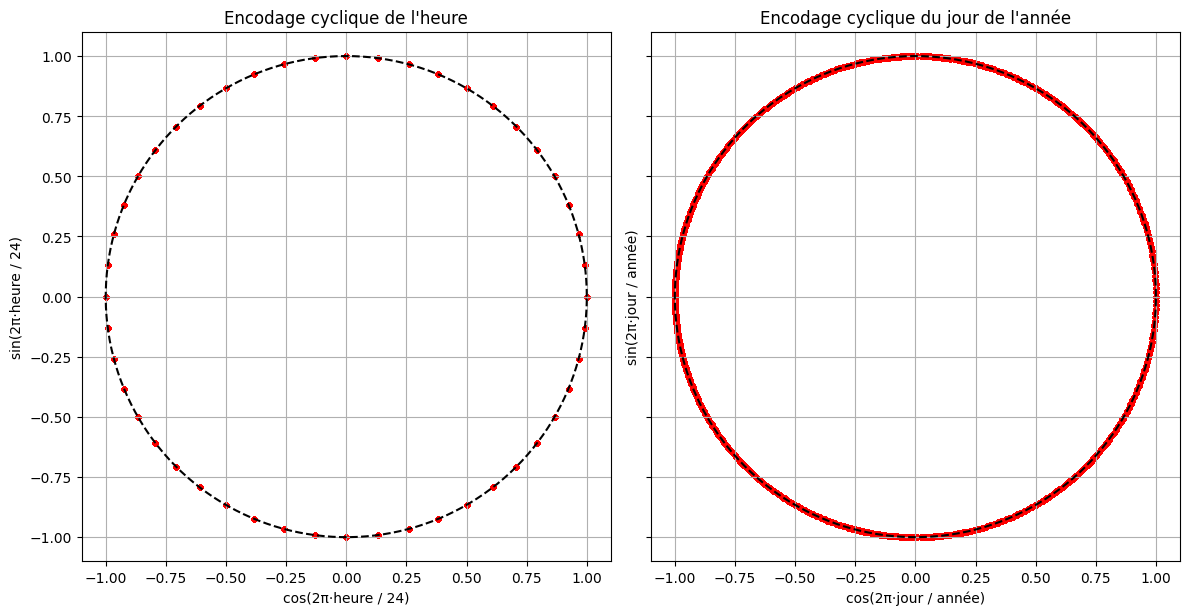


valid :


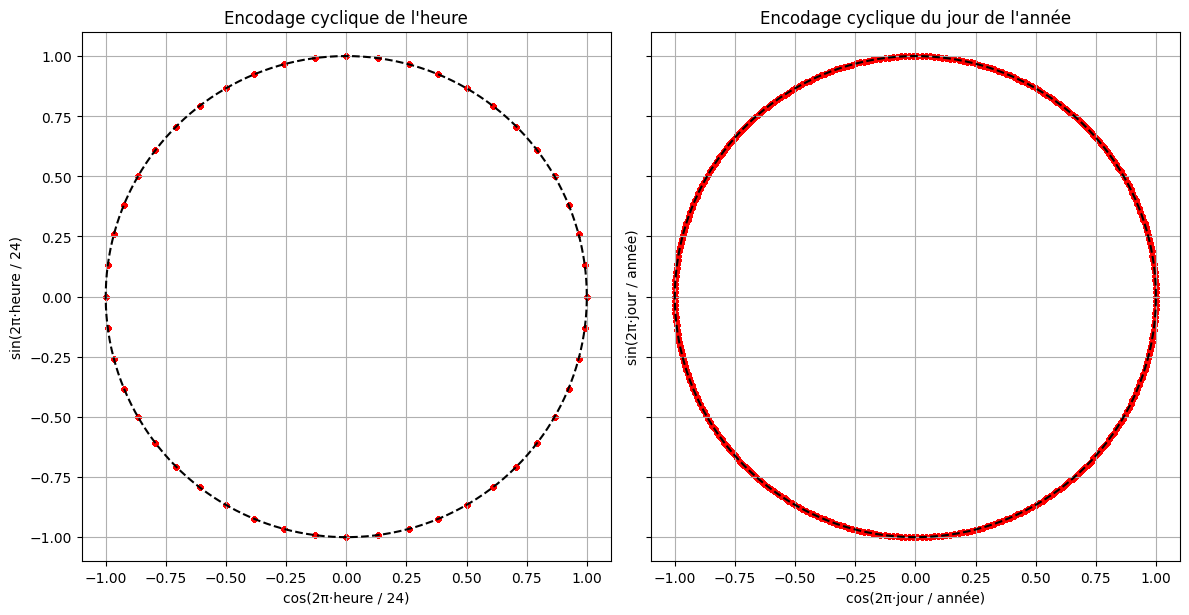


test :


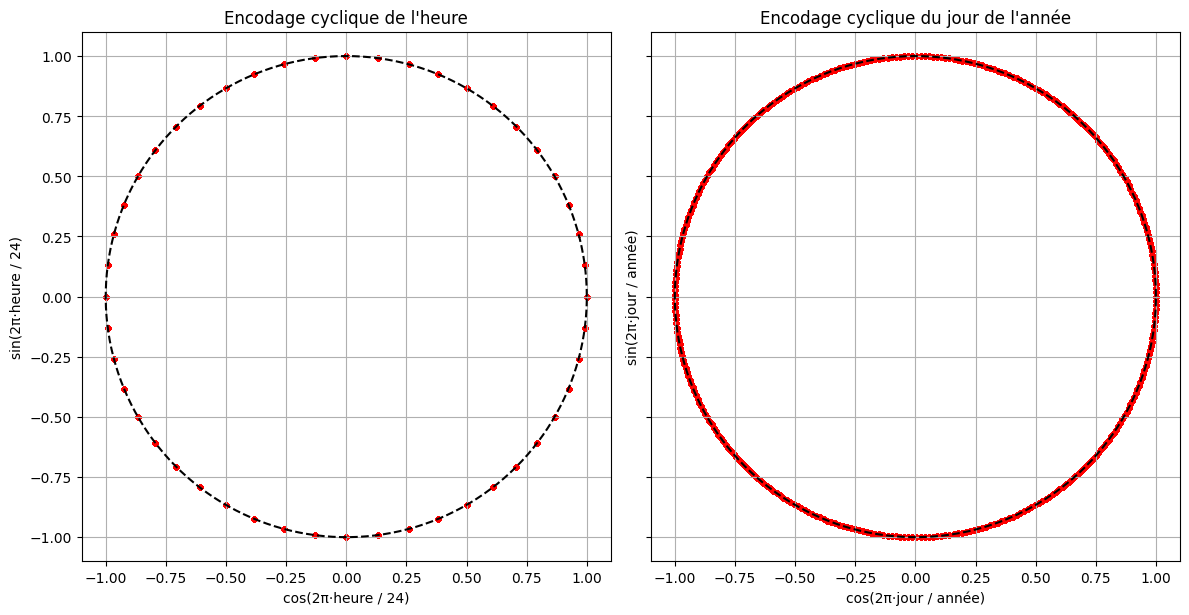

In [40]:
theta = np.linspace(0, 2*np.pi, 360)

for key, df in all_df.items():
    print(f"\n{key} :")
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

    # --- Subplot 1 : Encodage cyclique de l'heure ---
    ax = axes[0]
    ax.scatter(df['cos_hour'], df['sin_hour'], alpha=0.5, s=10, c='red')
    ax.plot(np.cos(theta), np.sin(theta), 'k--')  # cercle unité
    ax.set_xlabel("cos(2π·heure / 24)")
    ax.set_ylabel("sin(2π·heure / 24)")
    ax.set_title("Encodage cyclique de l'heure")
    ax.grid(True)
    ax.set_aspect('equal', adjustable='box')

    # --- Subplot 2 : Encodage cyclique du jour de l'année ---
    ax = axes[1]
    ax.scatter(df['cos_doy'], df['sin_doy'], alpha=0.5, s=10, c='red')
    ax.plot(np.cos(theta), np.sin(theta), 'k--')  # cercle unité
    ax.set_xlabel("cos(2π·jour / année)")
    ax.set_ylabel("sin(2π·jour / année)")
    ax.set_title("Encodage cyclique du jour de l'année")
    ax.grid(True)
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()
    

Les points rouges sont répartis sur le cercle unité, illustrant le caractère cyclique des variables temporelles : les heures proches de minuit (23 h et 0 h) ainsi que les jours situés aux extrémités de l'année (31 décembre et 1er janvier) restent voisins dans l'espace encodé, contrairement à un encodage linéaire.


### 3 - Continuité de l'encodage cyclique

Les composantes sinus et cosinus varient de manière continue au cours de la journée.


train :


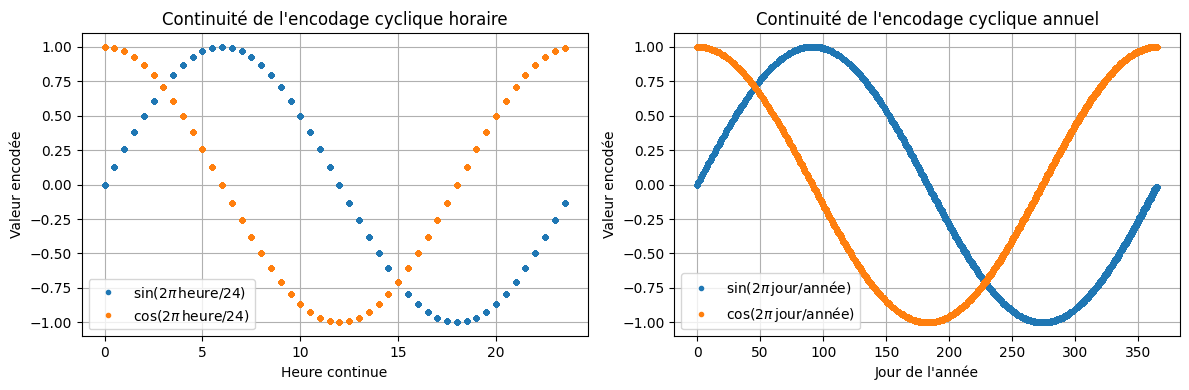


valid :


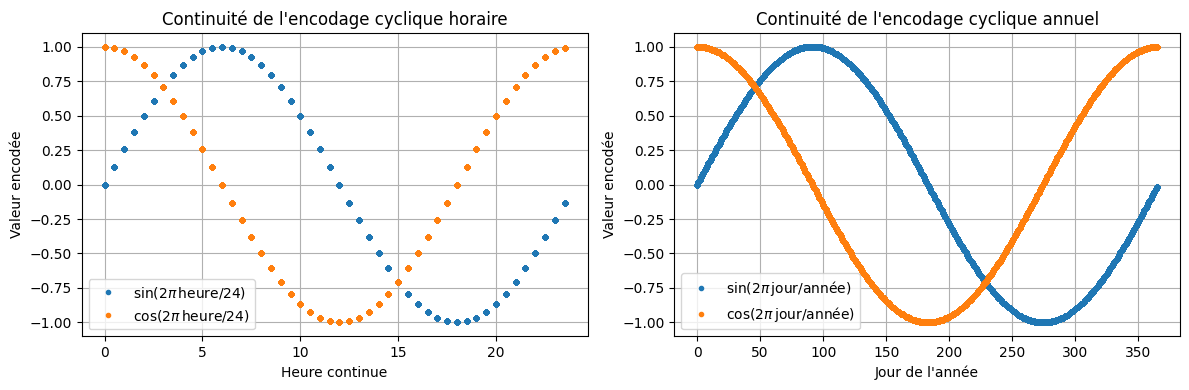


test :


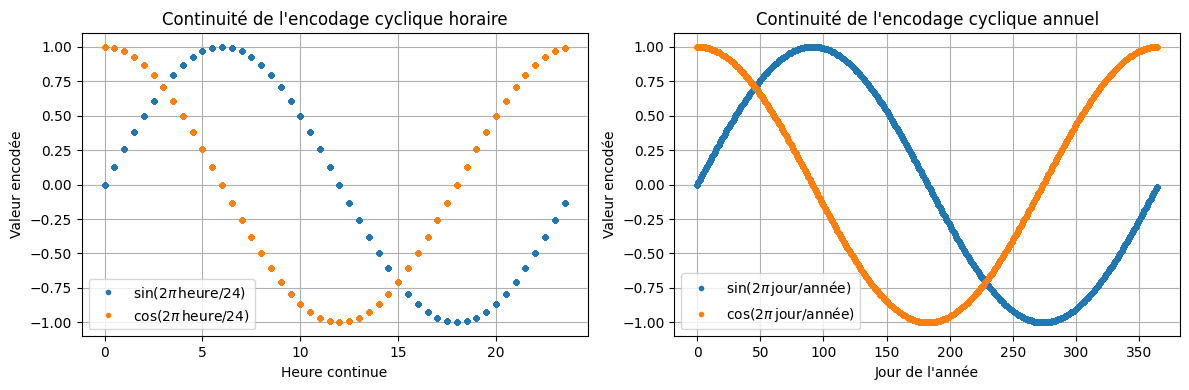

In [50]:
for key, df in all_df.items():
    
    # Encodage cyclique de l'heure (continu, heure + minutes)
    hour = df.index.hour + df.index.minute / 60
    doy = df.index.dayofyear - 1

    print(f"\n{key} :")
    plt.figure(figsize=(12, 4))

    # --- Plot 1 : Encodage cyclique de l'heure ---
    plt.subplot(1, 2, 1)
    plt.plot(hour, df['sin_hour'], '.', label=r'$\sin(2\pi\,\mathrm{heure}/24)$')
    plt.plot(hour, df['cos_hour'], '.', label=r'$\cos(2\pi\,\mathrm{heure}/24)$')
    plt.xlabel("Heure continue")
    plt.ylabel("Valeur encodée")
    plt.title("Continuité de l'encodage cyclique horaire")
    plt.legend()
    plt.grid(True)

    # --- Plot 2 : Encodage cyclique du jour de l'année ---
    plt.subplot(1, 2, 2)
    plt.plot(doy, df['sin_doy'], '.', label=r'$\sin(2\pi\,\mathrm{jour}/\mathrm{année})$')
    plt.plot(doy, df['cos_doy'], '.', label=r'$\cos(2\pi\,\mathrm{jour}/\mathrm{année})$')
    plt.xlabel("Jour de l'année")
    plt.ylabel("Valeur encodée")
    plt.title("Continuité de l'encodage cyclique annuel")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    

### 4 - Continuité autour de minuit et du changement d'année


train :


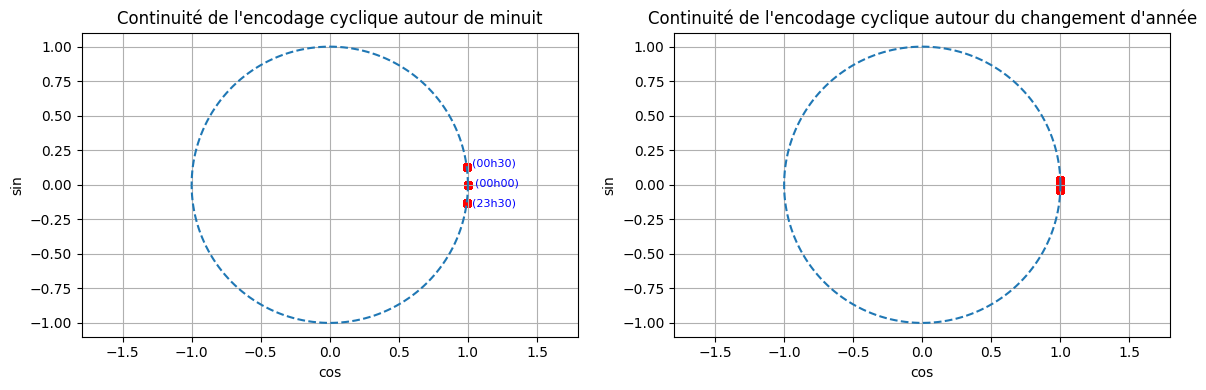


valid :


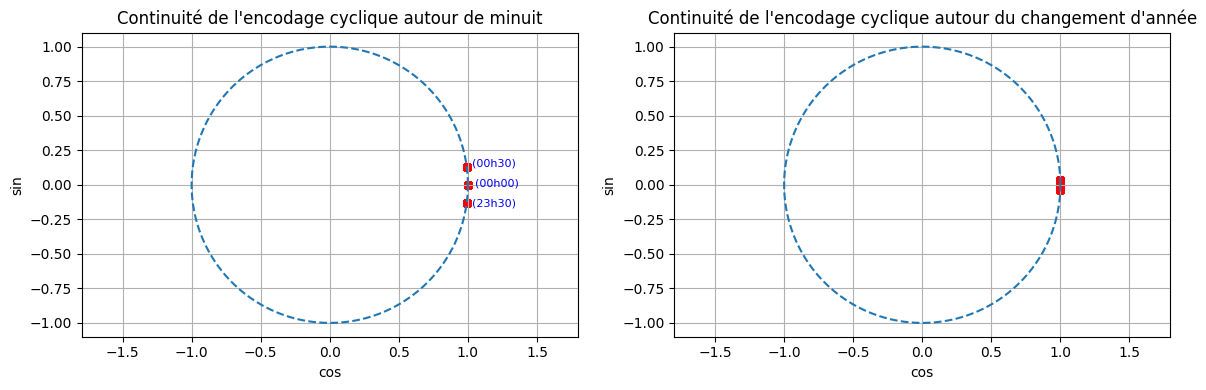


test :


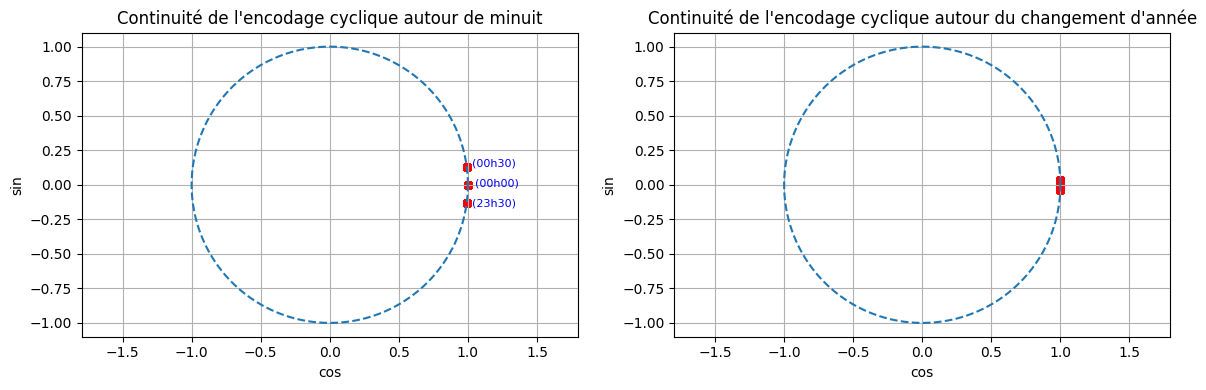

In [53]:
# Masques autour des discontinuités apparentes
for key, df in all_df.items():
    
    # Encodage cyclique de l'heure (continu, heure + minutes)
    hour = df.index.hour + df.index.minute / 60
    doy = df.index.dayofyear - 1
    year_len = np.where(df.index.is_leap_year, 366, 365)

    print(f"\n{key} :")
    
    mask_hour = (hour < 1) | (hour > 23)
    mask_day  = (doy < 3) | (doy > (year_len - 3))

    theta = np.linspace(0, 2*np.pi, 360)

    plt.figure(figsize=(12, 4))

    # --- Subplot 1 : Continuité autour de minuit ---
    plt.subplot(1, 2, 1)
    plt.scatter(df.loc[mask_hour, 'cos_hour'],
                df.loc[mask_hour, 'sin_hour'],
                color='red', s=30)

    plt.plot(np.cos(theta), np.sin(theta), linestyle='--')
    plt.axis('equal')
    plt.xlabel("cos")
    plt.ylabel("sin")
    plt.title("Continuité de l'encodage cyclique autour de minuit")
    plt.grid(True)

    plt.text(1.05, -0.01, f"(00h00)", fontsize=8, color='blue')
    plt.text(1.03, 0.13, f"(00h30)", fontsize=8, color='blue')
    plt.text(1.03, -0.16, f"(23h30)", fontsize=8, color='blue')

    # --- Subplot 2 : Continuité autour du changement d'année ---
    plt.subplot(1, 2, 2)
    plt.scatter(df.loc[mask_day, 'cos_doy'],
                df.loc[mask_day, 'sin_doy'],
                color='red', s=30)

    plt.plot(np.cos(theta), np.sin(theta), linestyle='--')
    plt.axis('equal')
    plt.xlabel("cos")
    plt.ylabel("sin")
    plt.title("Continuité de l'encodage cyclique autour du changement d'année")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

L'utilisation d'un encodage cyclique basé sur les fonctions sinus et cosinus permet de préserver la continuité temporelle de l'heure, notamment autour de la transition minuit, contrairement à un encodage linéaire classique.


In [ ]:
# Sauvegarde des datasets 
for key, df in all_df.items():
    

# III - Ajout de variables

Variables de mémoire et de variations


In [59]:
# Nombre de pas de temps correspondant aux fenêtres
window_2h = 4   # 2 heures = 4 pas de 30 minutes
window_4h = 8   # 4 heures = 8 pas de 30 minutes

### 1 - Irradiance solaire

**BNI – Beam (Direct) Normal Irradiance**  
Le $BNI$ correspond au rayonnement solaire direct mesuré sur un plan perpendiculaire aux rayons du soleil.  
Sur un plan horizontal, sa contribution s'écrit :
$$
BHI = BNI \cdot \cos(\theta_z)
$$
où $\theta_z = \dfrac{\pi}{2} - \alpha$ est l'angle zénithal solaire et $\alpha$ l'**altitude solaire**, définie comme l'angle entre le soleil et l'horizon.  
Le $BNI$ dépend donc fortement de la position instantanée du soleil et suppose une orientation optimale du capteur. Or, les panneaux photovoltaïques fixes ne sont pas toujours perpendiculaires aux rayons solaires et ne suivent généralement pas le soleil.

**GHI – Global Horizontal Irradiance**  
Le $GHI$ représente le rayonnement solaire total reçu sur un plan horizontal et s'exprime par :
$$
GHI = BHI + DHI = BNI \cdot \cos(\theta_z) + DHI
$$
où $DHI$ est l'irradiance diffuse horizontale.  
Le $GHI$ intègre ainsi les composantes directe et diffuse du rayonnement et décrit plus fidèlement l'irradiation réellement reçue par les panneaux photovoltaïques standards.

**Choix méthodologique**  
Dans notre projet, nous adoptons le **GHI** comme variable d'entrée principale, car il permet une analyse plus représentative et plus robuste de la variabilité de la production solaire à partir de données ouvertes.


In [60]:
## On supprime les variables dont la variance est trop faible
#colonnes_a_supprimer = [
#    'cru_clear_sky_bhi', 'cru_clear_sky_dhi', 'cru_clear_sky_bni', 'cru_bhi', 'cru_dhi', 'cru_bni',
#    'sel_clear_sky_bhi', 'sel_clear_sky_dhi', 'sel_clear_sky_bni', 'sel_bhi', 'sel_dhi', 'sel_bni',
#    'svt_clear_sky_bhi', 'svt_clear_sky_dhi', 'svt_clear_sky_bni', 'svt_bhi', 'svt_dhi', 'svt_bni',
#    'bra_clear_sky_bhi', 'bra_clear_sky_dhi', 'bra_clear_sky_bni', 'bra_bhi', 'bra_dhi', 'bra_bni',
#    'eyg_clear_sky_bhi', 'eyg_clear_sky_dhi', 'eyg_clear_sky_bni', 'eyg_bhi', 'eyg_dhi', 'eyg_bni']
#
#for key, df in all_df.items():
#    avant = df.shape[1]
#    df = df.drop(colonnes_a_supprimer, axis=1)
#    print(f"\n{key} : {avant} colonnes avant, {df.shape[1]} colonnes après suppression.")
#    

In [61]:
# GHI
for key, df in all_df.items():
    for ville in ['bra', 'cru', 'eyg', 'sel', 'svt'] :
        # Variation de l'irradiance
        df[ville+"_dghi_dt"] = df[ville+"_ghi"].diff()

        # Lags de l'irradiance
        df[ville+"_ghi_lag_1"] = df[ville+"_ghi"].shift(1)
        df[ville+"_ghi_lag_2"] = df[ville+"_ghi"].shift(2)

        # Lags de la variation de l'irradiance
        df[ville+"_dghi_lag_1"] = df[ville+"_dghi_dt"].shift(1)
        df[ville+"_dghi_lag_2"] = df[ville+"_dghi_dt"].shift(2)
        df[ville+"_dghi_lag_3"] = df[ville+"_dghi_dt"].shift(3)

        # Moyennes glissantes
        df[ville+"_ghi_mean_2h"] = df[ville+"_ghi"].rolling(window=window_2h).mean()
        df[ville+"_ghi_mean_4h"] = df[ville+"_ghi"].rolling(window=window_4h).mean()

        # Ecarts-type glissants
        df[ville+"_ghi_std_2h"] = df[ville+"_ghi"].rolling(window=window_2h).std()
        df[ville+"_ghi_std_4h"] = df[ville+"_ghi"].rolling(window=window_4h).std()

    print(f"{key} : taille de df -> {df.shape}")

train : taille de df -> (70130, 140)
valid : taille de df -> (17568, 140)
test : taille de df -> (17520, 140)


/tmp/ipykernel_14456/4118530108.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[ville+"_dghi_dt"] = df[ville+"_ghi"].diff()
/tmp/ipykernel_14456/4118530108.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[ville+"_ghi_lag_1"] = df[ville+"_ghi"].shift(1)
/tmp/ipykernel_14456/4118530108.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata

### D - Variations d'irradiance et de nébulosité

Les rampes de production photovoltaïque sont principalement déclenchées par des variations
rapides de l'irradiance solaire, généralement associées aux passages nuageux.

On considère donc les variations temporelles de l'irradiance globale et de la nébulosité :

$$
\Delta GHI(t) = GHI(t) - GHI(t-\Delta t)
$$

$$
\Delta \text{Nebulosite}(t) =
\text{Nebulosite}(t) -
\text{Nebulosite}(t-\Delta t)
$$
avec $\Delta t = 30$ minutes.

Ces variables capturent directement les transitions nuageuses responsables des rampes
de production photovoltaïque.


In [17]:
# Nébulosité
for ville in ['bra', 'cru', 'eyg', 'sel', 'svt'] :
    # Variation de la nébulosité
    df[ville+"_dnebulosite_dt"] = df[ville+"_nebulosite"].diff()
    
    # Lags de la nébulosité
    df[ville+"_nebulosite_lag_1"] = df[ville+"_nebulosite"].shift(1)
    df[ville+"_nebulosite_lag_2"] = df[ville+"_nebulosite"].shift(2)
    
    # Lags de la variation de la nébulosité
    df[ville+"_dnebulosite_lag_1"] = df[ville+"_dnebulosite_dt"].shift(1)
    df[ville+"_dnebulosite_lag_2"] = df[ville+"_dnebulosite_dt"].shift(2)

print(f"Taille de df : {df.shape}")

Taille de df : (107597, 159)


In [18]:
# TCH solaire
# Lags du TCH solaire
df["tch_lag_1"] = df["tch_solaire"].shift(1)
df["tch_lag_2"] = df["tch_solaire"].shift(2)
df["tch_lag_3"] = df["tch_solaire"].shift(3)
    
# Lags de la variation du TCH solaire
df["target_lag_1"] = df["target"].shift(1)
df["target_lag_2"] = df["target"].shift(2)
df["target_lag_3"] = df["target"].shift(3)

# Moyennes glissantes (calculées sur tch_lag_1 pour éviter la fuite de données)
df["tch_mean_2h"] = df["tch_lag_1"].rolling(window=window_2h).mean()
df["tch_mean_4h"] = df["tch_lag_1"].rolling(window=window_4h).mean()
    
# Ecarts-type glissants (calculés sur tch_lag_1 pour éviter la fuite de données)
df["tch_std_2h"] = df["tch_lag_1"].rolling(window=window_2h).std()
df["tch_std_4h"] = df["tch_lag_1"].rolling(window=window_4h).std()

print(f"Taille de df : {df.shape}")

Taille de df : (107597, 169)


In [19]:
df.info() # toutes les colonnes sont de type float64

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 107597 entries, 2019-12-31 23:00:00+00:00 to 2026-02-19 13:00:00+00:00
Columns: 169 entries, consommation to tch_std_4h
dtypes: float64(169)
memory usage: 143.6 MB


In [20]:
df = df.reindex(columns=df.columns.sort_values())
print(f"Taille de df : {df.shape}")
display(df.head())

Taille de df : (107597, 169)


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dghi_dt,bra_dghi_lag_1,...,target_lag_3,tch_lag_1,tch_lag_2,tch_lag_3,tch_mean_2h,tch_mean_4h,tch_solaire,tch_std_2h,tch_std_4h,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,-68.046190,335.241040,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
2019-12-31 23:30:00+00:00,-69.500739,353.945722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
2020-01-01 00:00:00+00:00,-69.141123,13.536657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,NaN,NaN,NaN,0.0,NaN,NaN,0.0
2020-01-01 00:30:00+00:00,-67.054165,31.240402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,0.0,0.0,0.0,NaN,NaN,0.0,NaN,NaN,0.0
2020-01-01 01:00:00+00:00,-63.656435,45.699703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,NaN,0.0


In [21]:
# Suppression des valeurs nulles introduites
df = df.dropna()
print(f"Taille de df : {df.shape}")

Taille de df : (107589, 169)


In [22]:
# On enregistre 3 datasets pour train / valid / test
df[date_debut_train : date_fin_train].to_csv("../../data/train_5pts.csv")
df[date_debut_valid : date_fin_valid].to_csv("../../data/valid_5pts.csv")
df[date_debut_test : date_fin_test].to_csv("../../data/test_5pts.csv")

In [23]:
# Check
print("Train :")
df_train = pd.read_csv("../../data/train_5pts.csv", index_col='datetime_utc', parse_dates=True)
display(df_train.head())
print("Taille du dataset :", df_train.shape)

print("\nValid :")
df_valid = pd.read_csv("../../data/valid_5pts.csv", index_col='datetime_utc', parse_dates=True)
display(df_valid.head())
print("Taille du dataset :", df_valid.shape)

print("\nTest :")
df_test = pd.read_csv("../../data/test_5pts.csv", index_col='datetime_utc', parse_dates=True)
display(df_test.head())
print("Taille du dataset :", df_test.shape)

Train :


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dghi_dt,bra_dghi_lag_1,...,target_lag_3,tch_lag_1,tch_lag_2,tch_lag_3,tch_mean_2h,tch_mean_4h,tch_solaire,tch_std_2h,tch_std_4h,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 03:00:00+00:00,-44.186485,80.264541,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 03:30:00+00:00,-38.785359,86.000566,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 04:00:00+00:00,-33.346881,91.256074,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 04:30:00+00:00,-27.918331,96.207025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-01 05:00:00+00:00,-22.539213,100.984524,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Taille du dataset : (70122, 169)

Valid :


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dghi_dt,bra_dghi_lag_1,...,target_lag_3,tch_lag_1,tch_lag_2,tch_lag_3,tch_mean_2h,tch_mean_4h,tch_solaire,tch_std_2h,tch_std_4h,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,-69.141088,13.532368,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 00:30:00+00:00,-67.054481,31.236592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 01:00:00+00:00,-63.657001,45.696549,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 01:30:00+00:00,-59.396982,57.119939,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2024-01-01 02:00:00+00:00,-54.603773,66.256046,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Taille du dataset : (17568, 169)

Test :


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dghi_dt,bra_dghi_lag_1,...,target_lag_3,tch_lag_1,tch_lag_2,tch_lag_3,tch_mean_2h,tch_mean_4h,tch_solaire,tch_std_2h,tch_std_4h,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,-69.097348,13.266719,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.0,0.0,0.04,0.02,0.030,0.0,0.023094,0.018516,0.0
2025-01-01 00:30:00+00:00,-67.033957,30.974224,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.04,0.0,0.0,0.00,0.01,0.025,0.0,0.020000,0.020702,0.0
2025-01-01 01:00:00+00:00,-63.654884,45.461256,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.0,0.0,0.00,0.00,0.020,0.0,0.000000,0.021381,0.0
2025-01-01 01:30:00+00:00,-59.407753,56.915724,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.0,0.0,0.00,0.00,0.015,0.0,0.000000,0.020702,0.0
2025-01-01 02:00:00+00:00,-54.623026,66.078554,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.0,0.0,0.00,0.00,0.010,0.0,0.000000,0.018516,0.0


Taille du dataset : (19899, 169)


In [24]:
# On va créé un second dataset avec moins de colonnes
# en utilisant des moyennes pondérées sur les colonnes concernant les 5 points d'intérêts retenus

# Récupération de la base des noms de colonnes concernés
col_par_ville = []
# Comme tous les points d'intérêts ont exactement les même colonnes les concernant
# On fait une recherche des noms concernant la ville de Bras
for col in df.columns :
    if col[:3] == "bra":
        col_par_ville.append(col[4:])
print(col_par_ville)
print("Nombre de colonnes concernant chaque point d'intérêt :", len(col_par_ville))

['altitude', 'azimuth', 'bhi', 'bni', 'clear_sky_bhi', 'clear_sky_bni', 'clear_sky_dhi', 'clear_sky_ghi', 'dghi_dt', 'dghi_lag_1', 'dghi_lag_2', 'dghi_lag_3', 'dhi', 'dnebulosite_dt', 'dnebulosite_lag_1', 'dnebulosite_lag_2', 'ghi', 'ghi_lag_1', 'ghi_lag_2', 'ghi_mean_2h', 'ghi_mean_4h', 'ghi_std_2h', 'ghi_std_4h', 'humidite', 'nebulosite', 'nebulosite_lag_1', 'nebulosite_lag_2', 'temperature', 'toa', 'vitesse_vent']
Nombre de colonnes concernant chaque point d'intérêt : 30


In [25]:
# Récupération des coefficients de pondération
# Chargement du fichier contenant les communes représentatives
# et leur contribution énergétique associée
df_communes = pd.read_csv("../../data/local_data/01_Clustering/output/best_communes_geo_energy.csv")

# Affichage des noms de colonnes pour vérification
display(df_communes)

# Passsage du préfixe en minuscule
df_communes['prefix'] = df_communes['prefix'].str.lower() 

# Récupération des coefficients de pondération
coeff_ponderation = []
for poids in df_communes['poids'] :
    coeff_ponderation.append(poids)
print(coeff_ponderation)

# Calcul de la somme pondérée
for col in col_par_ville:
    col_name_region = f"region_{col}"
    df[col_name_region] = 0.0
    
    # Récupération de tous les noms des colonnes à pondérer
    all_concerns_cols = []
    for ville in df_communes['prefix'] :
        all_concerns_cols.append(f"{ville}_{col}")
    
    # Calcul
    for poids, ville in zip(coeff_ponderation, all_concerns_cols):
        df[col_name_region] = df[col_name_region] + poids * df[ville]
    
    # Supression des colonnes devenues inutiles
    df = df.drop(all_concerns_cols, axis=1)

print(f"Taille de df : {df.shape}")

,cluster_geo,best_commune,code_insee,lat,lon,energie_totale,poids,prefix
0,2,Cruis,4065,44.0845,5.8397,20356525.0,0.22,CRU
1,4,Saint-Étienne-le-Laus,5140,44.5075,6.1616,325158.0,0.06,SEL
2,0,Saint-Vallier-de-Thiey,6130,43.6994,6.8516,344281.0,0.07,SVT
3,1,Bras,83021,43.4723,5.9558,10603661.0,0.29,BRA
4,3,Eygalières,13034,43.7638,4.9554,1510927.0,0.36,EYG


[0.22, 0.06, 0.07, 0.29, 0.36]
Taille de df : (107589, 49)


In [26]:
# On enregistre 3 datasets pour train / valid / test
df[date_debut_train : date_fin_train].to_csv("../../data/train_region.csv")
df[date_debut_valid : date_fin_valid].to_csv("../../data/valid_region.csv")
df[date_debut_test : date_fin_test].to_csv("../../data/test_region.csv")

In [27]:
# Check
print("Train :")
df_train = pd.read_csv("../../data/train_region.csv", index_col='datetime_utc', parse_dates=True)
display(df_train.head())
print("Taille du dataset :", df_train.shape)

print("\nValid :")
df_valid = pd.read_csv("../../data/valid_region.csv", index_col='datetime_utc', parse_dates=True)
display(df_valid.head())
print("Taille du dataset :", df_valid.shape)

print("\nTest :")
df_test = pd.read_csv("../../data/test_region.csv", index_col='datetime_utc', parse_dates=True)
display(df_test.head())
print("Taille du dataset :", df_test.shape)

Train :


,consommation,cos_doy,cos_hour,sin_doy,sin_hour,solaire,target,target_lag_1,target_lag_2,target_lag_3,...,region_ghi_mean_4h,region_ghi_std_2h,region_ghi_std_4h,region_humidite,region_nebulosite,region_nebulosite_lag_1,region_nebulosite_lag_2,region_temperature,region_toa,region_vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2020-01-01 03:00:00+00:00,5332.0,1.0,0.707107,0.0,0.707107,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,73.3023,32.16660,19.95190,7.7372,3.36130,0.0,0.96980
2020-01-01 03:30:00+00:00,5219.0,1.0,0.608761,0.0,0.793353,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,72.5645,32.21870,32.16660,19.9519,3.26355,0.0,0.97035
2020-01-01 04:00:00+00:00,5157.0,1.0,0.500000,0.0,0.866025,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,71.8267,32.27080,32.21870,32.1666,3.16580,0.0,0.97090
2020-01-01 04:30:00+00:00,5161.0,1.0,0.382683,0.0,0.923880,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,70.5524,32.58025,32.27080,32.2187,3.22595,0.0,0.98650
2020-01-01 05:00:00+00:00,5108.0,1.0,0.258819,0.0,0.965926,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,69.2781,32.88970,32.58025,32.2708,3.28610,0.0,1.00210


Taille du dataset : (70122, 49)

Valid :


,consommation,cos_doy,cos_hour,sin_doy,sin_hour,solaire,target,target_lag_1,target_lag_2,target_lag_3,...,region_ghi_mean_4h,region_ghi_std_2h,region_ghi_std_4h,region_humidite,region_nebulosite,region_nebulosite_lag_1,region_nebulosite_lag_2,region_temperature,region_toa,region_vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,4812.0,1.0,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,96.33220,91.8536,88.0609,84.2682,2.66020,0.0,2.47700
2024-01-01 00:30:00+00:00,4833.0,1.0,0.991445,0.0,0.130526,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,95.95980,94.0952,91.8536,88.0609,2.58245,0.0,2.45855
2024-01-01 01:00:00+00:00,4863.0,1.0,0.965926,0.0,0.258819,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,95.58740,96.3368,94.0952,91.8536,2.50470,0.0,2.44010
2024-01-01 01:30:00+00:00,4903.0,1.0,0.923880,0.0,0.382683,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,95.19045,97.7836,96.3368,94.0952,2.47905,0.0,2.39285
2024-01-01 02:00:00+00:00,4737.0,1.0,0.866025,0.0,0.500000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,94.79350,99.2304,97.7836,96.3368,2.45340,0.0,2.34560


Taille du dataset : (17568, 49)

Test :


,consommation,cos_doy,cos_hour,sin_doy,sin_hour,solaire,target,target_lag_1,target_lag_2,target_lag_3,...,region_ghi_mean_4h,region_ghi_std_2h,region_ghi_std_4h,region_humidite,region_nebulosite,region_nebulosite_lag_1,region_nebulosite_lag_2,region_temperature,region_toa,region_vitesse_vent
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,5277.0,1.0,1.000000,0.0,0.000000,0.0,0.0,0.0,-0.04,0.00,...,0.0,0.0,0.0,85.42900,68.10510,64.53005,60.95500,3.7956,0.0,0.7248
2025-01-01 00:30:00+00:00,5314.0,1.0,0.991445,0.0,0.130526,0.0,0.0,0.0,0.00,-0.04,...,0.0,0.0,0.0,85.57575,67.91415,68.10510,64.53005,3.7172,0.0,0.7478
2025-01-01 01:00:00+00:00,5262.0,1.0,0.965926,0.0,0.258819,0.0,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,85.72250,67.72320,67.91415,68.10510,3.6388,0.0,0.7708
2025-01-01 01:30:00+00:00,5287.0,1.0,0.923880,0.0,0.382683,0.0,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,85.41155,69.23185,67.72320,67.91415,3.6087,0.0,0.7865
2025-01-01 02:00:00+00:00,5070.0,1.0,0.866025,0.0,0.500000,0.0,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,85.10060,70.74050,69.23185,67.72320,3.5786,0.0,0.8022


Taille du dataset : (19899, 49)
